In [13]:
PREPROCESSED_DIR = "/kaggle/input/datasets/iftekharuddin27/preprocessed-datasets"  
OUTPUT_DIR = "/kaggle/working/"

English: Train=83,455, Val=10,432
Bangla:  Train=67,009, Val=8,376
Extracting English features...
Extracting Bangla features...
Building improved TF-IDF for English...
Building improved TF-IDF for Bangla...
MODEL 1: LOGISTIC REGRESSION (Improved) - English

LR (Improved) - English
Accuracy: 0.8072
Macro F1: 0.8071
              precision    recall  f1-score   support

 Non-hateful       0.75      0.72      0.74      3470
     Hateful       0.90      0.87      0.89      3485
   Sarcastic       0.77      0.83      0.80      3477

    accuracy                           0.81     10432
   macro avg       0.81      0.81      0.81     10432
weighted avg       0.81      0.81      0.81     10432



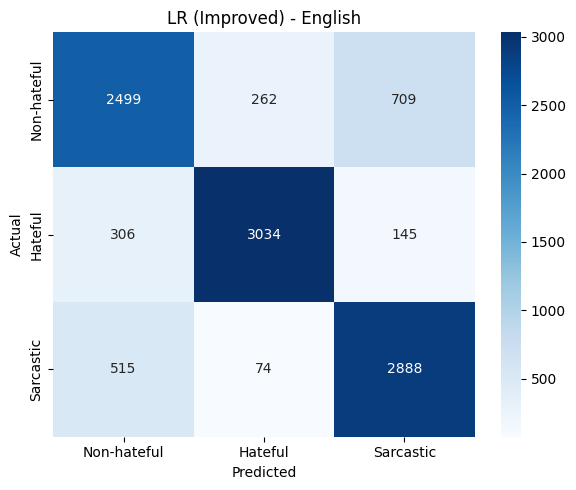

MODEL 1: LOGISTIC REGRESSION (Improved) - Bangla

LR (Improved) - Bangla
Accuracy: 0.7810
Macro F1: 0.7616
              precision    recall  f1-score   support

 Non-hateful       0.80      0.79      0.79      4140
     Hateful       0.89      0.86      0.87      2560
   Sarcastic       0.60      0.64      0.62      1676

    accuracy                           0.78      8376
   macro avg       0.76      0.76      0.76      8376
weighted avg       0.78      0.78      0.78      8376



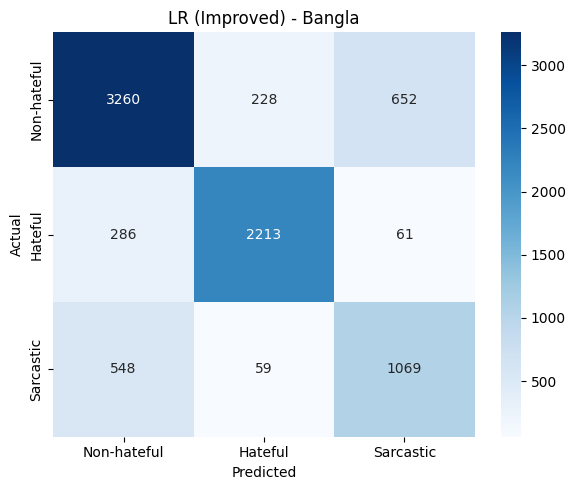

In [2]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix
import warnings

warnings.filterwarnings('ignore')

# Constants
CLASS_NAMES = {0: 'Non-hateful', 1: 'Hateful', 2: 'Sarcastic'}
all_results = []

en_train = pd.read_csv(f"{PREPROCESSED_DIR}/en_train.csv")
en_val = pd.read_csv(f"{PREPROCESSED_DIR}/en_val.csv")
bn_train = pd.read_csv(f"{PREPROCESSED_DIR}/bn_train.csv")
bn_val = pd.read_csv(f"{PREPROCESSED_DIR}/bn_val.csv")

# Fill missing values in the text column
for df in [en_train, en_val, bn_train, bn_val]:
    df['text_clean'] = df['text_clean'].fillna('')

# Prepare target variables
y_en_train = en_train['class'].values
y_en_val = en_val['class'].values
y_bn_train = bn_train['label'].values
y_bn_val = bn_val['label'].values

print(f"English: Train={len(en_train):,}, Val={len(en_val):,}")
print(f"Bangla:  Train={len(bn_train):,}, Val={len(bn_val):,}")

# Feature extraction function for English
def extract_english_features(df):
    texts = df['text_clean'].fillna('')
    features = pd.DataFrame()
    features['char_count'] = texts.str.len()
    features['word_count'] = texts.str.split().str.len().fillna(0)
    features['avg_word_len'] = texts.apply(lambda t: np.mean([len(w) for w in str(t).split()]) if len(str(t).split()) > 0 else 0)
    features['exclamation_count'] = texts.str.count('!')
    features['question_count'] = texts.str.count(r'\?')
    features['period_count'] = texts.str.count(r'\.')
    features['comma_count'] = texts.str.count(',')
    features['ellipsis_count'] = texts.str.count(r'\.\.\.')
    features['quote_count'] = texts.str.count('"') + texts.str.count("'")
    features['has_profanity'] = texts.apply(lambda t: int(any(w in str(t).split() for w in {'shit', 'fuck', 'fucking', 'bitch', 'ass'})))
    features['negation_count'] = texts.apply(lambda t: len(re.findall(r'\b(not|no|never|nothing)\b', str(t), re.IGNORECASE)))
    features['unique_word_ratio'] = texts.apply(lambda t: len(set(str(t).split())) / max(len(str(t).split()), 1))
    return features

# Extract English features
print("Extracting English features...")
en_train_feat = extract_english_features(en_train)
en_val_feat = extract_english_features(en_val)

# Feature extraction function for Bangla
def extract_bangla_features(df):
    texts = df['text_clean'].fillna('')
    features = pd.DataFrame()
    features['char_count'] = texts.str.len()
    features['word_count'] = texts.str.split().str.len().fillna(0)
    features['avg_word_len'] = texts.apply(lambda t: np.mean([len(w) for w in str(t).split()]) if len(str(t).split()) > 0 else 0)
    features['exclamation_count'] = texts.str.count('!')
    features['question_count'] = texts.str.count(r'\?')
    features['period_count'] = texts.str.count(r'\.')
    features['bangla_danda_count'] = texts.str.count('।')  # Bangla period
    features['has_emoji_text'] = texts.apply(lambda t: int(bool(re.search(r'[:;][-]?[)(DPp]', str(t)))))
    features['english_word_count'] = texts.apply(lambda t: len(re.findall(r'[a-zA-Z]{2,}', str(t))))
    features['repeated_chars'] = texts.apply(lambda t: len(re.findall(r'(.)\1{2,}', str(t))))
    features['unique_word_ratio'] = texts.apply(lambda t: len(set(str(t).split())) / max(len(str(t).split()), 1))
    return features

# Extract Bangla features
print("Extracting Bangla features...")
bn_train_feat = extract_bangla_features(bn_train)
bn_val_feat = extract_bangla_features(bn_val)

# TF-IDF for English (Reduced max_features for faster computation)
print("Building improved TF-IDF for English...")
tfidf_en_word = TfidfVectorizer(max_features=5000, ngram_range=(1, 3), sublinear_tf=True, min_df=2, max_df=0.95, analyzer='word')
X_en_train_word = tfidf_en_word.fit_transform(en_train['text_clean'])
X_en_val_word = tfidf_en_word.transform(en_val['text_clean'])

tfidf_en_char = TfidfVectorizer(max_features=5000, ngram_range=(3, 5), sublinear_tf=True, min_df=2, max_df=0.95, analyzer='char_wb')
X_en_train_char = tfidf_en_char.fit_transform(en_train['text_clean'])
X_en_val_char = tfidf_en_char.transform(en_val['text_clean'])

scaler_en = StandardScaler()
X_en_train_eng = scaler_en.fit_transform(en_train_feat.values)
X_en_val_eng = scaler_en.transform(en_val_feat.values)

X_en_train_combined = hstack([X_en_train_word, X_en_train_char, csr_matrix(X_en_train_eng)])
X_en_val_combined = hstack([X_en_val_word, X_en_val_char, csr_matrix(X_en_val_eng)])

# TF-IDF for Bangla (Reduced max_features for faster computation)
print("Building improved TF-IDF for Bangla...")
tfidf_bn_word = TfidfVectorizer(max_features=5000, ngram_range=(1, 3), sublinear_tf=True, min_df=2, max_df=0.95, analyzer='word')
X_bn_train_word = tfidf_bn_word.fit_transform(bn_train['text_clean'])
X_bn_val_word = tfidf_bn_word.transform(bn_val['text_clean'])

tfidf_bn_char = TfidfVectorizer(max_features=5000, ngram_range=(3, 6), sublinear_tf=True, min_df=2, max_df=0.95, analyzer='char_wb')
X_bn_train_char = tfidf_bn_char.fit_transform(bn_train['text_clean'])
X_bn_val_char = tfidf_bn_char.transform(bn_val['text_clean'])

scaler_bn = StandardScaler()
X_bn_train_eng = scaler_bn.fit_transform(bn_train_feat.values)
X_bn_val_eng = scaler_bn.transform(bn_val_feat.values)

X_bn_train_combined = hstack([X_bn_train_word, X_bn_train_char, csr_matrix(X_bn_train_eng)])
X_bn_val_combined = hstack([X_bn_val_word, X_bn_val_char, csr_matrix(X_bn_val_eng)])

# Logistic Regression for English (Using 'liblinear' solver for faster execution)
print("=" * 70)
print("MODEL 1: LOGISTIC REGRESSION (Improved) - English")
print("=" * 70)
lr_en = LogisticRegression(max_iter=500, C=5.0, solver='liblinear', random_state=42, n_jobs=-1)
lr_en.fit(X_en_train_combined, y_en_train)
lr_en_pred = lr_en.predict(X_en_val_combined)

# Evaluation for English model
def evaluate_model(model_name, y_true, y_pred, dataset_name, save_cm=True):
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    print(f"\n{'='*60}")
    print(f"{model_name} - {dataset_name}")
    print(f"{'='*60}")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1: {f1_macro:.4f}")
    print(classification_report(y_true, y_pred, target_names=list(CLASS_NAMES.values())))
    if save_cm:
        cm = confusion_matrix(y_true, y_pred)
        fig, ax = plt.subplots(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES.values(), yticklabels=CLASS_NAMES.values(), ax=ax)
        ax.set_title(f'{model_name} - {dataset_name}')
        ax.set_ylabel('Actual'); ax.set_xlabel('Predicted')
        plt.tight_layout()
        plt.show()

evaluate_model("LR (Improved)", y_en_val, lr_en_pred, "English")

# Logistic Regression for Bangla (Using 'liblinear' solver for faster execution)
print("=" * 70)
print("MODEL 1: LOGISTIC REGRESSION (Improved) - Bangla")
print("=" * 70)
lr_bn = LogisticRegression(max_iter=500, C=5.0, solver='liblinear', class_weight='balanced', random_state=42, n_jobs=-1)
lr_bn.fit(X_bn_train_combined, y_bn_train)
lr_bn_pred = lr_bn.predict(X_bn_val_combined)

# Evaluation for Bangla model
evaluate_model("LR (Improved)", y_bn_val, lr_bn_pred, "Bangla")

MODEL 2: SVM (Improved)

SVM (Improved) - English
Accuracy: 0.8060
Macro F1: 0.8060
              precision    recall  f1-score   support

 Non-hateful       0.75      0.72      0.74      3470
     Hateful       0.90      0.87      0.88      3485
   Sarcastic       0.77      0.83      0.80      3477

    accuracy                           0.81     10432
   macro avg       0.81      0.81      0.81     10432
weighted avg       0.81      0.81      0.81     10432



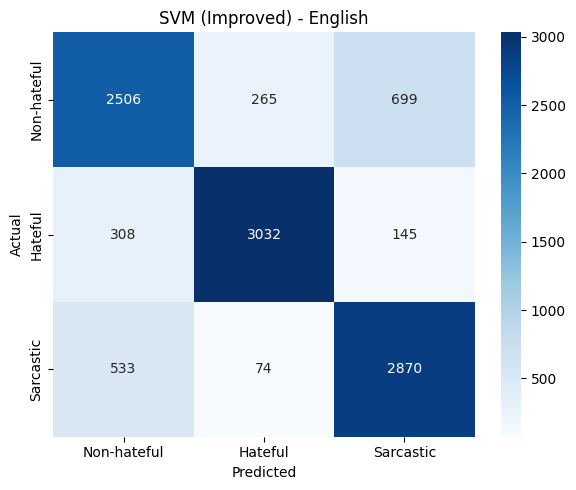


SVM (Improved) - Bangla
Accuracy: 0.7789
Macro F1: 0.7588
              precision    recall  f1-score   support

 Non-hateful       0.79      0.79      0.79      4140
     Hateful       0.88      0.86      0.87      2560
   Sarcastic       0.60      0.63      0.61      1676

    accuracy                           0.78      8376
   macro avg       0.76      0.76      0.76      8376
weighted avg       0.78      0.78      0.78      8376



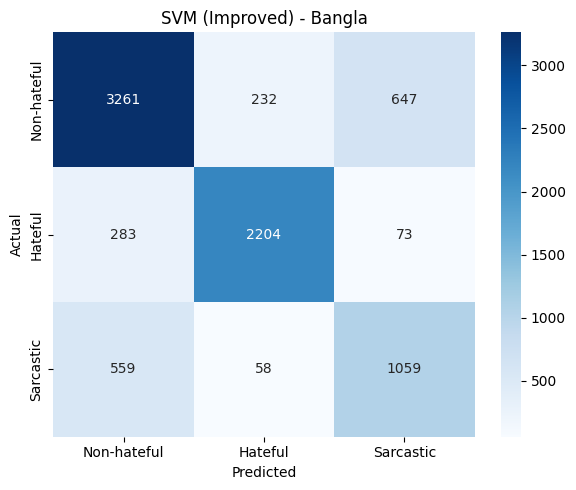

In [5]:
# Add the necessary import for LinearSVC
from sklearn.svm import LinearSVC

# ============================================================
# MODEL 2: SVM (Tuned)
# ============================================================
print("=" * 70)
print("MODEL 2: SVM (Improved)")
print("=" * 70)

# English
svm_en = LinearSVC(max_iter=5000, C=1.0, random_state=42, loss='squared_hinge')
svm_en.fit(X_en_train_combined, y_en_train)
svm_en_pred = svm_en.predict(X_en_val_combined)
evaluate_model("SVM (Improved)", y_en_val, svm_en_pred, "English")

# Bangla
svm_bn = LinearSVC(max_iter=5000, C=1.0, class_weight='balanced',
                    random_state=42, loss='squared_hinge')
svm_bn.fit(X_bn_train_combined, y_bn_train)
svm_bn_pred = svm_bn.predict(X_bn_val_combined)
evaluate_model("SVM (Improved)", y_bn_val, svm_bn_pred, "Bangla")

MODEL 3: SGD Classifier

SGD Classifier - English
Accuracy: 0.7928
Macro F1: 0.7920
              precision    recall  f1-score   support

 Non-hateful       0.74      0.68      0.71      3470
     Hateful       0.89      0.86      0.87      3485
   Sarcastic       0.75      0.84      0.79      3477

    accuracy                           0.79     10432
   macro avg       0.79      0.79      0.79     10432
weighted avg       0.79      0.79      0.79     10432



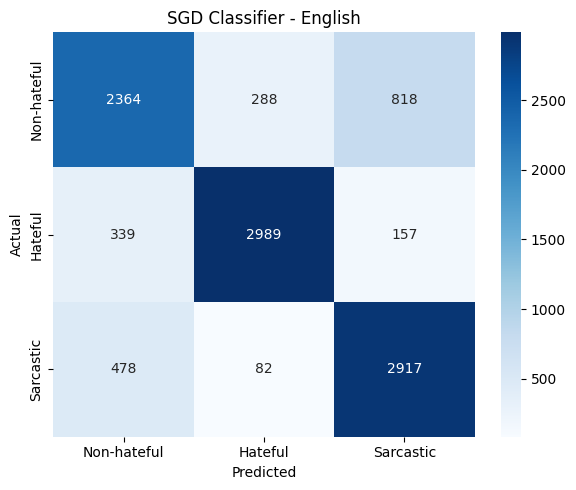


SGD Classifier - Bangla
Accuracy: 0.7502
Macro F1: 0.7302
              precision    recall  f1-score   support

 Non-hateful       0.77      0.76      0.77      4140
     Hateful       0.86      0.83      0.85      2560
   Sarcastic       0.55      0.61      0.58      1676

    accuracy                           0.75      8376
   macro avg       0.73      0.73      0.73      8376
weighted avg       0.76      0.75      0.75      8376



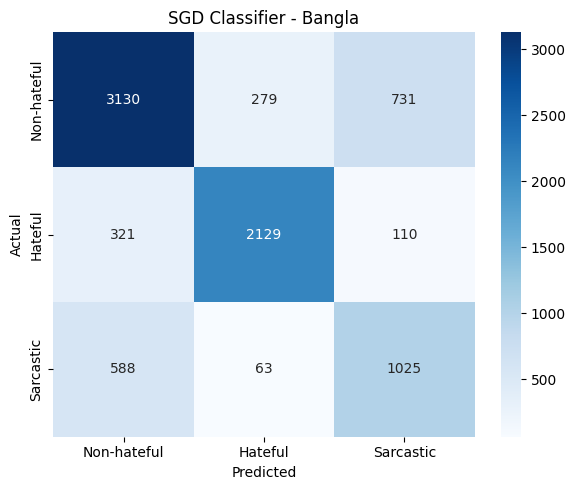

In [6]:

# %% [code]
# ============================================================
# MODEL 3: SGD Classifier (faster SVM variant, works well with large sparse data)
# ============================================================
from sklearn.linear_model import SGDClassifier

print("=" * 70)
print("MODEL 3: SGD Classifier")
print("=" * 70)

# English
sgd_en = SGDClassifier(
    loss='modified_huber',  # gives probability estimates too
    max_iter=1000, random_state=42, n_jobs=-1,
    alpha=1e-5, penalty='l2'
)
sgd_en.fit(X_en_train_combined, y_en_train)
sgd_en_pred = sgd_en.predict(X_en_val_combined)
evaluate_model("SGD Classifier", y_en_val, sgd_en_pred, "English")

# Bangla
sgd_bn = SGDClassifier(
    loss='modified_huber', max_iter=1000, random_state=42,
    n_jobs=-1, alpha=1e-5, penalty='l2', class_weight='balanced'
)
sgd_bn.fit(X_bn_train_combined, y_bn_train)
sgd_bn_pred = sgd_bn.predict(X_bn_val_combined)
evaluate_model("SGD Classifier", y_bn_val, sgd_bn_pred, "Bangla")


MODEL 4: LR Hyperparameter Tuning
  English C=0.1: Macro F1 = 0.7578
  Bangla  C=0.1: Macro F1 = 0.7394
  English C=0.5: Macro F1 = 0.7598
  Bangla  C=0.5: Macro F1 = 0.7456
  English C=1.0: Macro F1 = 0.7597
  Bangla  C=1.0: Macro F1 = 0.7464
  English C=2.0: Macro F1 = 0.7601
  Bangla  C=2.0: Macro F1 = 0.7471
  English C=5.0: Macro F1 = 0.7602
  Bangla  C=5.0: Macro F1 = 0.7471
  English C=10.0: Macro F1 = 0.7601
  Bangla  C=10.0: Macro F1 = 0.7468

Best English: C=5.0, Macro F1=0.7602
Best Bangla: C=5.0, Macro F1=0.7471

LR (Best C) - English
Accuracy: 0.7606
Macro F1: 0.7602
              precision    recall  f1-score   support

 Non-hateful       0.70      0.64      0.67      3470
     Hateful       0.88      0.82      0.85      3485
   Sarcastic       0.71      0.82      0.76      3477

    accuracy                           0.76     10432
   macro avg       0.76      0.76      0.76     10432
weighted avg       0.76      0.76      0.76     10432



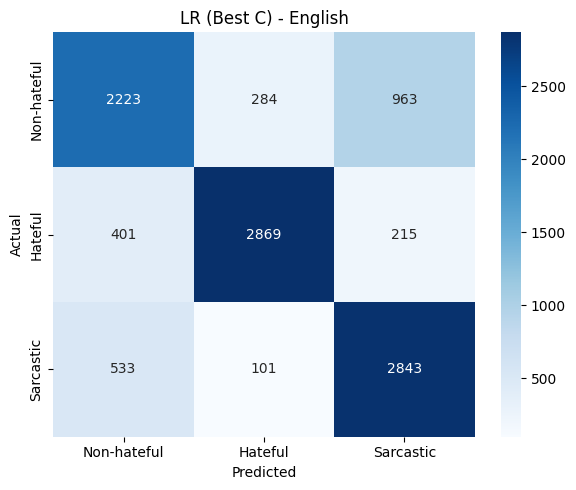


LR (Best C) - Bangla
Accuracy: 0.7553
Macro F1: 0.7471
              precision    recall  f1-score   support

 Non-hateful       0.83      0.69      0.75      4140
     Hateful       0.87      0.86      0.86      2560
   Sarcastic       0.53      0.77      0.63      1676

    accuracy                           0.76      8376
   macro avg       0.74      0.77      0.75      8376
weighted avg       0.78      0.76      0.76      8376



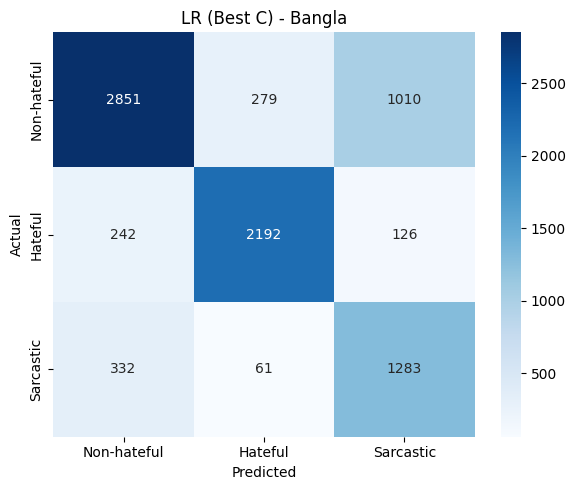

In [7]:

# %% [code]
# ============================================================
# MODEL 4: Logistic Regression with DIFFERENT C values (hyperparameter search)
# ============================================================
print("=" * 70)
print("MODEL 4: LR Hyperparameter Tuning")
print("=" * 70)

best_en_f1 = 0
best_en_C = 1.0
best_bn_f1 = 0
best_bn_C = 1.0

for C in [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]:
    # English
    lr = LogisticRegression(max_iter=2000, C=C, solver='saga', random_state=42, n_jobs=-1)
    lr.fit(X_en_train_combined, y_en_train)
    pred = lr.predict(X_en_val_combined)
    f1 = f1_score(y_en_val, pred, average='macro')
    print(f"  English C={C}: Macro F1 = {f1:.4f}")
    if f1 > best_en_f1:
        best_en_f1 = f1
        best_en_C = C
    
    # Bangla
    lr = LogisticRegression(max_iter=2000, C=C, solver='saga',
                            class_weight='balanced', random_state=42, n_jobs=-1)
    lr.fit(X_bn_train_combined, y_bn_train)
    pred = lr.predict(X_bn_val_combined)
    f1 = f1_score(y_bn_val, pred, average='macro')
    print(f"  Bangla  C={C}: Macro F1 = {f1:.4f}")
    if f1 > best_bn_f1:
        best_bn_f1 = f1
        best_bn_C = C

print(f"\nBest English: C={best_en_C}, Macro F1={best_en_f1:.4f}")
print(f"Best Bangla: C={best_bn_C}, Macro F1={best_bn_f1:.4f}")

# Train with best C and save
lr_en_best = LogisticRegression(max_iter=2000, C=best_en_C, solver='saga',
                                 random_state=42, n_jobs=-1)
lr_en_best.fit(X_en_train_combined, y_en_train)
lr_en_best_pred = lr_en_best.predict(X_en_val_combined)
evaluate_model("LR (Best C)", y_en_val, lr_en_best_pred, "English")

lr_bn_best = LogisticRegression(max_iter=2000, C=best_bn_C, solver='saga',
                                 class_weight='balanced', random_state=42, n_jobs=-1)
lr_bn_best.fit(X_bn_train_combined, y_bn_train)
lr_bn_best_pred = lr_bn_best.predict(X_bn_val_combined)
evaluate_model("LR (Best C)", y_bn_val, lr_bn_best_pred, "Bangla")


MODEL 5: Ensemble (Soft Voting)
Training English ensemble...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(



Ensemble - English
Accuracy: 0.8035
Macro F1: 0.8032
              precision    recall  f1-score   support

 Non-hateful       0.75      0.70      0.73      3470
     Hateful       0.90      0.86      0.88      3485
   Sarcastic       0.76      0.84      0.80      3477

    accuracy                           0.80     10432
   macro avg       0.81      0.80      0.80     10432
weighted avg       0.81      0.80      0.80     10432



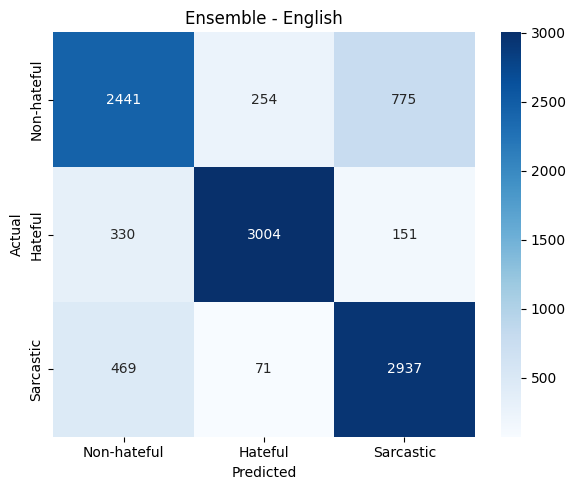

Training Bangla ensemble...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Ensemble - Bangla
Accuracy: 0.7732
Macro F1: 0.7546
              precision    recall  f1-score   support

 Non-hateful       0.79      0.78      0.79      4140
     Hateful       0.89      0.84      0.86      2560
   Sarcastic       0.58      0.64      0.61      1676

    accuracy                           0.77      8376
   macro avg       0.75      0.76      0.75      8376
weighted avg       0.78      0.77      0.78      8376



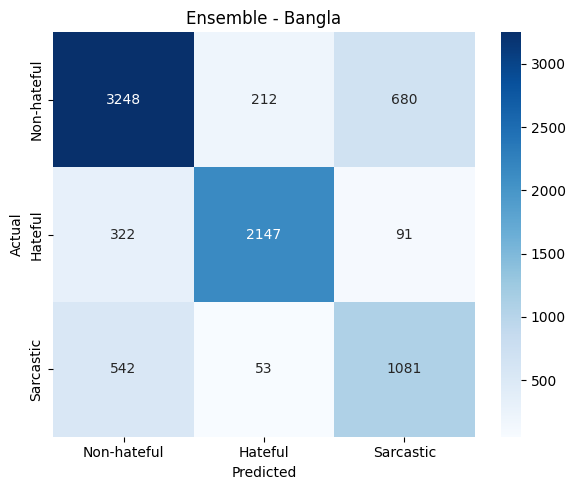

In [9]:

# %% [code]
# ============================================================
# MODEL 5: Ensemble (Voting Classifier)
# ============================================================
# Add the necessary imports
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import SGDClassifier
print("=" * 70)
print("MODEL 5: Ensemble (Soft Voting)")
print("=" * 70)

# English Ensemble
from sklearn.calibration import CalibratedClassifierCV

svm_calibrated_en = CalibratedClassifierCV(
    LinearSVC(max_iter=5000, C=1.0, random_state=42), cv=3
)

ensemble_en = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=2000, C=best_en_C, solver='saga',
                                   random_state=42, n_jobs=-1)),
        ('svm', svm_calibrated_en),
        ('sgd', SGDClassifier(loss='modified_huber', max_iter=1000,
                               random_state=42, n_jobs=-1, alpha=1e-5)),
    ],
    voting='soft', n_jobs=-1
)
print("Training English ensemble...")
ensemble_en.fit(X_en_train_combined, y_en_train)
ens_en_pred = ensemble_en.predict(X_en_val_combined)
evaluate_model("Ensemble", y_en_val, ens_en_pred, "English")

# Bangla Ensemble
svm_calibrated_bn = CalibratedClassifierCV(
    LinearSVC(max_iter=5000, C=1.0, class_weight='balanced', random_state=42), cv=3
)

ensemble_bn = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(max_iter=2000, C=best_bn_C, solver='saga',
                                   class_weight='balanced', random_state=42, n_jobs=-1)),
        ('svm', svm_calibrated_bn),
        ('sgd', SGDClassifier(loss='modified_huber', max_iter=1000, class_weight='balanced',
                               random_state=42, n_jobs=-1, alpha=1e-5)),
    ],
    voting='soft', n_jobs=-1
)
print("Training Bangla ensemble...")
ensemble_bn.fit(X_bn_train_combined, y_bn_train)
ens_bn_pred = ensemble_bn.predict(X_bn_val_combined)
evaluate_model("Ensemble", y_bn_val, ens_bn_pred, "Bangla")


BANGLA EXTRA: Training with Oversampled Data
Oversampled Bangla: {0: 33119, 1: 33119, 2: 33119}

LR (Oversampled) - Bangla
Accuracy: 0.7642
Macro F1: 0.7552
              precision    recall  f1-score   support

 Non-hateful       0.83      0.71      0.76      4140
     Hateful       0.87      0.86      0.87      2560
   Sarcastic       0.55      0.76      0.63      1676

    accuracy                           0.76      8376
   macro avg       0.75      0.78      0.76      8376
weighted avg       0.79      0.76      0.77      8376



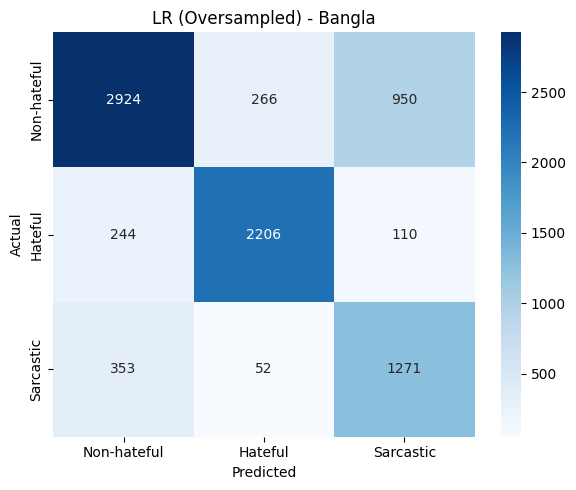

In [10]:
# ============================================================
# BANGLA-SPECIFIC: Oversampling the minority class
# ============================================================
print("=" * 70)
print("BANGLA EXTRA: Training with Oversampled Data")
print("=" * 70)

# Simple random oversampling of sarcastic class
from sklearn.utils import resample

bn_train_with_features = bn_train.copy()
bn_train_with_features['_idx'] = range(len(bn_train_with_features))

# Separate by class
class_0 = bn_train_with_features[bn_train_with_features['label'] == 0]
class_1 = bn_train_with_features[bn_train_with_features['label'] == 1]
class_2 = bn_train_with_features[bn_train_with_features['label'] == 2]

target_size = len(class_0)  # Upsample to match majority class

class_1_up = resample(class_1, replace=True, n_samples=target_size, random_state=42)
class_2_up = resample(class_2, replace=True, n_samples=target_size, random_state=42)

bn_oversampled = pd.concat([class_0, class_1_up, class_2_up]).reset_index(drop=True)
print(f"Oversampled Bangla: {bn_oversampled['label'].value_counts().sort_index().to_dict()}")

# Re-extract features for oversampled data
bn_over_feat = extract_bangla_features(bn_oversampled)

# Fix: Define bn_feat_cols_no_source to filter out columns starting with 'source_'
bn_feat_cols_no_source = [col for col in bn_over_feat.columns if not col.startswith('source_')]

X_bn_over_word = tfidf_bn_word.transform(bn_oversampled['text_clean'].fillna(''))
X_bn_over_char = tfidf_bn_char.transform(bn_oversampled['text_clean'].fillna(''))
X_bn_over_eng = scaler_bn.transform(bn_over_feat[bn_feat_cols_no_source].values)

X_bn_over_combined = hstack([X_bn_over_word, X_bn_over_char, csr_matrix(X_bn_over_eng)])
y_bn_over = bn_oversampled['label'].values

# Train LR on oversampled data (no class weights needed since balanced now)
lr_bn_over = LogisticRegression(max_iter=2000, C=5.0, solver='saga',
                                 random_state=42, n_jobs=-1)
lr_bn_over.fit(X_bn_over_combined, y_bn_over)
lr_bn_over_pred = lr_bn_over.predict(X_bn_val_combined)
evaluate_model("LR (Oversampled)", y_bn_val, lr_bn_over_pred, "Bangla")